In [38]:
import numpy as np
import matplotlib.pyplot as plt
import math
import copy

In [75]:
x_train = np.array([[952, 1244, 1947, 1725, 1959, 1314, 864, 1836, 1026, 1602, 2104, 1380],[2, 3, 3, 3, 3, 2, 2, 3, 3, 3, 4, 2],[1, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 1],[65, 64, 17, 42, 15, 14, 66, 25, 43, 34, 8, 51]])
x_train = x_train.T
y_train = np.array([271.5, 232.0, 509.8, 394.0, 540.0, 415.0, 230.0, 460.0, 294.0, 412.0, 620.0, 305.0])
print(x_train.shape, y_train.shape)
print(x_train)

(12, 4) (12,)
[[ 952    2    1   65]
 [1244    3    2   64]
 [1947    3    2   17]
 [1725    3    2   42]
 [1959    3    2   15]
 [1314    2    1   14]
 [ 864    2    1   66]
 [1836    3    1   25]
 [1026    3    1   43]
 [1602    3    2   34]
 [2104    4    2    8]
 [1380    2    1   51]]


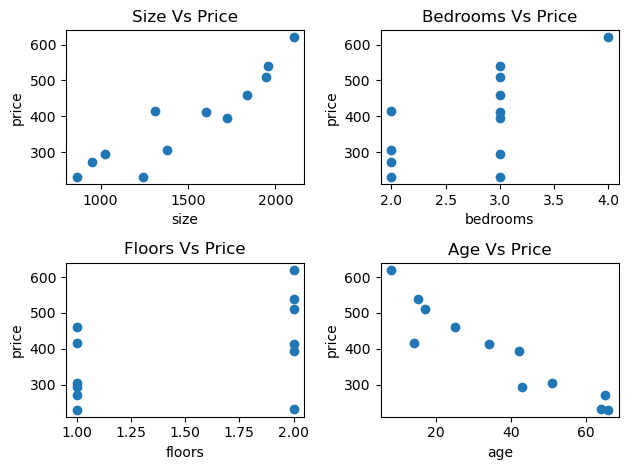

In [76]:
#drawing subplote
figure, ax = plt.subplots(2, 2)

ax[0][0].set_title("Size Vs Price")
ax[0][0].set_xlabel("size")
ax[0][0].set_ylabel("price")
ax[0][0].scatter(x_train[:, 0], y_train)


ax[0][1].set_title("Bedrooms Vs Price")
ax[0][1].set_xlabel("bedrooms")
ax[0][1].set_ylabel("price")
ax[0][1].scatter(x_train[:, 1], y_train)

ax[1][0].set_title("Floors Vs Price")
ax[1][0].set_xlabel("floors")
ax[1][0].set_ylabel("price")
ax[1][0].scatter(x_train[:, 2], y_train)

ax[1][1].set_title("Age Vs Price")
ax[1][1].set_xlabel("age")
ax[1][1].set_ylabel("price")
ax[1][1].scatter(x_train[:,3], y_train)


plt.tight_layout()
plt.show()

In [77]:
# this function requires optimal value of w and b
def predict(x, w, b):
    prediction = np.dot(x, w) + b;

    return prediction

In [78]:
def compute_cost(x, y, w, b):

    m = x.shape[0]
    cost = 0
    
    for i in range(m):
        cost += ((np.dot(x[i], w) + b) - y[i]) ** 2

    cost /= 2 * m

    return cost

In [79]:
def compute_gradient(x, y, w, b):

    m = x.shape[0]
    n = w.shape[0]

    dj_dw = np.zeros(n)
    dj_db = 0

    for i in range(m):
        partial = ((np.dot(x[i], w) + b) - y[i])
        dj_db += partial
        
        for j in range(n):
            dj_dw[j] += partial * x[i][j]

    dj_dw /= m
    dj_db /= m
    
    return dj_dw, dj_db

In [109]:
def gradient_descent(x, y, w_init, b_init, alpha, iterations, threshold):
    
    # cost history for calculating appropriate learning rate 
    j_history = []

    w = copy.deepcopy(w_init)
    b = b_init

    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(x, y, w, b)

        w = w - (alpha * dj_dw)
        b = b - (alpha * dj_db)

        cost = compute_cost(x, y, w, b)
        j_history.append(cost)

        if(i % math.ceil(iterations /10) == 0):
            print(f"Iteration: {i}, cost: {j_history[-1]}, dw_dj: {dj_dw}, dw_db: {dj_db}")
        
        if(np.all(abs(dj_dw) < threshold) and abs(dj_db) < threshold):
            print(f"Iteration: {i}, cost: {j_history[-1]}, dw_dj: {dj_dw}, dw_db: {dj_db}")

            break;
        
    return j_history, w, b
        

In [81]:
# training data unscaled
alpha = np.array([1e-8, 1e-7, 5e-7, 1e-6, 5e-6])
alpha_size = alpha.shape[0]
threshold = 0.5
iterations = 10000
w_init = np.zeros(4)
b_init = 0

cost_history = [0, 0, 0, 0,0]
for i in range(alpha_size):
    print(f"Learning rate: {alpha[i]}")

    cost_history[i], _, _ = gradient_descent(x_train, y_train, w_init, b_init, alpha[i], iterations, threshold)



Learning rate: 1e-08
Iteration: 0, cost: 79609.65415096229, dw_dj: [-6.29400383e+05 -1.12070000e+03 -6.15925000e+02 -1.21220917e+04], dw_db: -390.27500000000003
Iteration: 1000, cost: 1143.6928433384858, dw_dj: [-12.2891501    1.69855446   6.51791938 606.89584612], dw_db: 1.349734606469428
Iteration: 2000, cost: 1140.037127080218, dw_dj: [-12.19074174   1.6466623    6.49438643 602.03969615], dw_db: 1.3090443794056223
Iteration: 3000, cost: 1136.4396783925686, dw_dj: [-12.09313753   1.59518543   6.47104176 597.22240709], dw_db: 1.2686797757532062
Iteration: 4000, cost: 1132.8995684367653, dw_dj: [-11.9963144    1.54412056   6.44788389 592.44366829], dw_db: 1.22863820007926
Iteration: 5000, cost: 1129.4158831805767, dw_dj: [-11.9002661    1.4934644    6.42491132 587.70317125], dw_db: 1.1889170673584246
Iteration: 6000, cost: 1125.987723162296, dw_dj: [-11.80498642   1.44321366   6.40212256 583.00060995], dw_db: 1.1495138132521892
Iteration: 7000, cost: 1122.6142032584553, dw_dj: [-11.710

C:\Users\absentpirate\AppData\Local\Temp\ipykernel_10416\4240638545.py:7: RuntimeWarning: overflow encountered in scalar add
  cost += ((np.dot(x[i], w) + b) - y[i]) ** 2
C:\Users\absentpirate\AppData\Local\Temp\ipykernel_10416\4240638545.py:7: RuntimeWarning: overflow encountered in scalar power
  cost += ((np.dot(x[i], w) + b) - y[i]) ** 2
C:\Users\absentpirate\AppData\Local\Temp\ipykernel_10416\573447769.py:14: RuntimeWarning: overflow encountered in scalar add
  dj_dw[j] += partial * x[i][j]
C:\Users\absentpirate\AppData\Local\Temp\ipykernel_10416\3935322321.py:12: RuntimeWarning: invalid value encountered in subtract
  w = w - (alpha * dj_dw)


Iteration: 4000, cost: nan, dw_dj: [nan nan nan nan], dw_db: nan
Iteration: 5000, cost: nan, dw_dj: [nan nan nan nan], dw_db: nan
Iteration: 6000, cost: nan, dw_dj: [nan nan nan nan], dw_db: nan
Iteration: 7000, cost: nan, dw_dj: [nan nan nan nan], dw_db: nan
Iteration: 8000, cost: nan, dw_dj: [nan nan nan nan], dw_db: nan
Iteration: 9000, cost: nan, dw_dj: [nan nan nan nan], dw_db: nan
Learning rate: 5e-06
Iteration: 0, cost: 10017345.525837624, dw_dj: [-6.29400383e+05 -1.12070000e+03 -6.15925000e+02 -1.21220917e+04], dw_db: -390.27500000000003


C:\Users\absentpirate\AppData\Local\Temp\ipykernel_10416\573447769.py:14: RuntimeWarning: overflow encountered in scalar multiply
  dj_dw[j] += partial * x[i][j]


Iteration: 1000, cost: nan, dw_dj: [nan nan nan nan], dw_db: nan
Iteration: 2000, cost: nan, dw_dj: [nan nan nan nan], dw_db: nan
Iteration: 3000, cost: nan, dw_dj: [nan nan nan nan], dw_db: nan
Iteration: 4000, cost: nan, dw_dj: [nan nan nan nan], dw_db: nan
Iteration: 5000, cost: nan, dw_dj: [nan nan nan nan], dw_db: nan
Iteration: 6000, cost: nan, dw_dj: [nan nan nan nan], dw_db: nan
Iteration: 7000, cost: nan, dw_dj: [nan nan nan nan], dw_db: nan
Iteration: 8000, cost: nan, dw_dj: [nan nan nan nan], dw_db: nan
Iteration: 9000, cost: nan, dw_dj: [nan nan nan nan], dw_db: nan


In [110]:
# feature scaling

def z_scaling_features(x):
    mean = np.mean(x, axis = 0)
    sigma = np.std(x, axis = 0)

    x_normalized = (x - mean) / sigma

    return x_normalized, mean, sigma

range_before = np.ptp(x_train, axis = 0)
print("Not normalized:")
print(f"Size: {range_before[0]}, bedrooms: {range_before[1]}, floors: {range_before[2]}, age: {range_before[3]}")
x_normalized, mean, sigma = z_scaling_features(x_train)
range_after = np.ptp(x_normalized, axis = 0)
print("Normalized: ")
print(f"Size: {range_after[0]}, bedrooms: {range_after[1]}, floors: {range_after[2]}, age: {range_after[3]}")

Not normalized:
Size: 1240, bedrooms: 2, floors: 1, age: 58
Normalized: 
Size: 3.0426547479751362, bedrooms: 3.3606722016672235, floors: 2.0, age: 2.8363073349912753


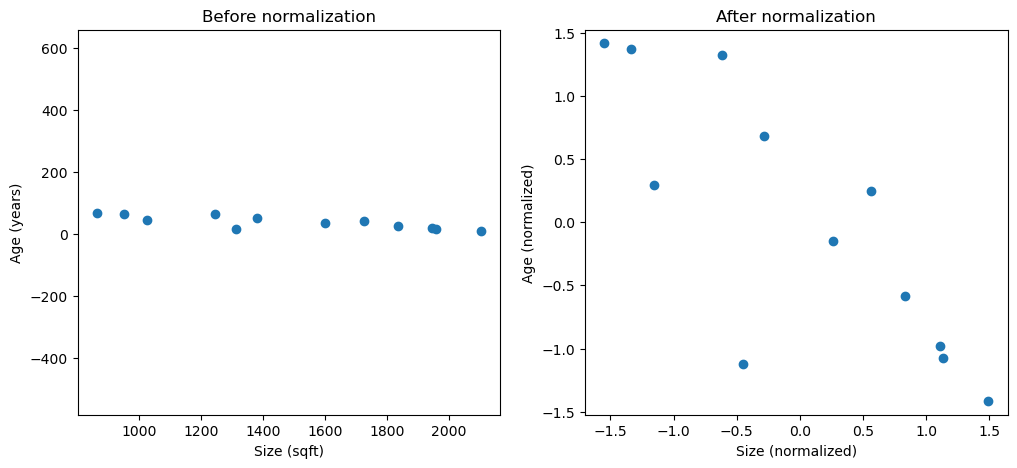

In [111]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(x_train[:, 0], x_train[:, 3])
ax[0].set_xlabel("Size (sqft)")
ax[0].set_ylabel("Age (years)")
ax[0].set_title("Before normalization")
ax[0].axis('equal')

ax[1].scatter(x_normalized[:, 0], x_normalized[:, 3])
ax[1].set_xlabel("Size (normalized)")
ax[1].set_ylabel("Age (normalized)")
ax[1].set_title("After normalization")
ax[1].axis('equal')

plt.show()

Learning rate: 0.001
Iteration: 0, cost: 83337.33610461158, dw_dj: [-111.68618903  -79.72144588  -61.025       113.35856485], dw_db: -390.27500000000003
Iteration: 1000, cost: 10925.901046953208, dw_dj: [-10.91811301   2.30750068   6.87341979  18.34572388], dw_db: -143.50233190248795
Iteration: 2000, cost: 1806.216387918813, dw_dj: [-3.21273275  3.82145388  5.16940625  6.78939614], dw_db: -52.765150884508785
Iteration: 3000, cost: 552.4717014043712, dw_dj: [-1.70312788  2.32980673  2.47682278  3.09328795], dw_db: -19.4015045675833
Iteration: 4000, cost: 376.9026610097599, dw_dj: [-1.05289938  1.40335194  1.10766147  1.40811407], dw_db: -7.133844463174012
Iteration: 5000, cost: 351.35485271874495, dw_dj: [-0.70873381  0.88287398  0.47038051  0.6008667 ], dw_db: -2.6230819701364205
Iteration: 6000, cost: 347.23434246626704, dw_dj: [-0.51305686  0.58136157  0.18522419  0.21507551], dw_db: -0.9644952392186591
Iteration: 7000, cost: 346.3645047485366, dw_dj: [-0.39420697  0.39832271  0.0646

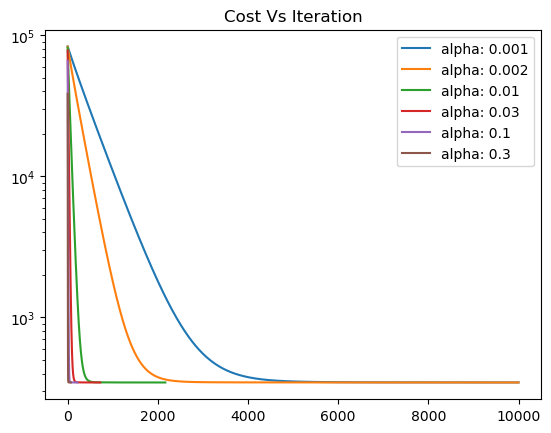

In [128]:
# training data scaled
alpha = np.array([0.001, 0.002, 0.01, 0.03, 0.1, 0.3])
alpha_size = alpha.shape[0]
threshold = 0.05
iterations = 10000
w_init = np.zeros(4)
b_init = 0

cost_history = [0] * alpha_size
for i in range(alpha_size):
    print(f"Learning rate: {alpha[i]}")

    cost_history[i], _, _ = gradient_descent(x_normalized, y_train, w_init, b_init, alpha[i], iterations, threshold)

plt.title("Cost Vs Iteration")
for i in range(alpha_size):
    label_1 = f"alpha: {alpha[i]}"
    plt.plot(cost_history[i], label=label_1)
    plt.yscale('log')
    
plt.legend()
plt.show()

Learning rate: 0.3
Iteration: 0, cost: 38500.793172481295, dw_dj: [-111.68618903  -79.72144588  -61.025       113.35856485], dw_db: -390.27500000000003
Iteration: 119, cost: 345.5302190560135, dw_dj: [-0.00972376  0.00047145  0.00411514 -0.00695487], dw_db: -7.105427357601002e-14


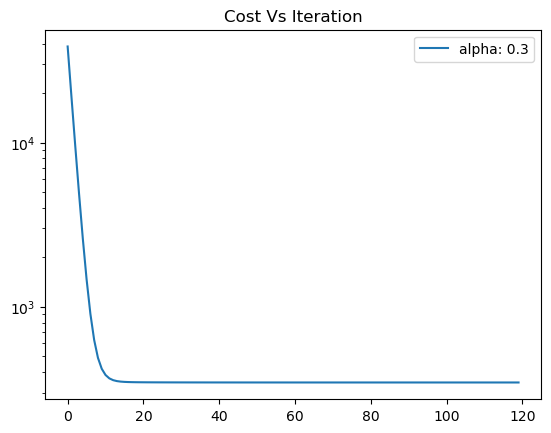

In [142]:
# training data scaled
alpha = np.array([0.3])
alpha_size = alpha.shape[0]
threshold = 0.01
iterations = 10000
w_init = np.zeros(4)
b_init = 0

cost_history = [0] * alpha_size
for i in range(alpha_size):
    print(f"Learning rate: {alpha[i]}")

    cost_history[i], final_w, final_b = gradient_descent(x_normalized, y_train, w_init, b_init, alpha[i], iterations, threshold)

plt.title("Cost Vs Iteration")
for i in range(alpha_size):
    label_1 = f"alpha: {alpha[i]}"
    plt.plot(cost_history[i], label=label_1)
    plt.yscale('log')
    
plt.legend()
plt.show()

In [143]:
# seeing prediction

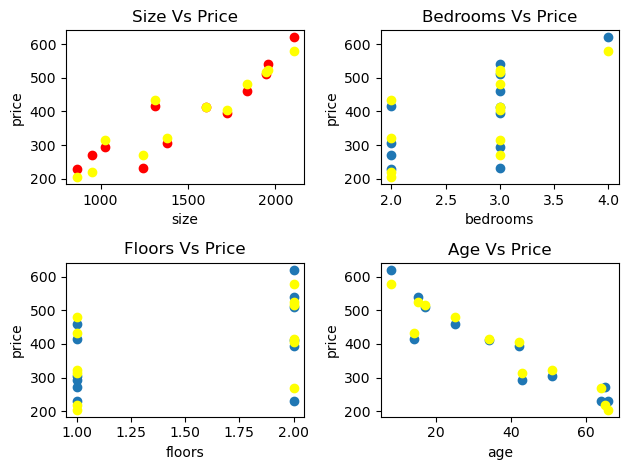

In [146]:
#drawing subplote
figure, ax = plt.subplots(2, 2)
prediction = predict(x_normalized, final_w, final_b)


ax[0][0].set_title("Size Vs Price")
ax[0][0].set_xlabel("size")
ax[0][0].set_ylabel("price")
ax[0][0].scatter(x_train[:, 0], y_train, color="red")
ax[0][0].scatter(x_train[:, 0], prediction, color="yellow")



ax[0][1].set_title("Bedrooms Vs Price")
ax[0][1].set_xlabel("bedrooms")
ax[0][1].set_ylabel("price")
ax[0][1].scatter(x_train[:, 1], y_train)
ax[0][1].scatter(x_train[:, 1], prediction, color="yellow")


ax[1][0].set_title("Floors Vs Price")
ax[1][0].set_xlabel("floors")
ax[1][0].set_ylabel("price")
ax[1][0].scatter(x_train[:, 2], y_train)
ax[1][0].scatter(x_train[:, 2], prediction, color="yellow")


ax[1][1].set_title("Age Vs Price")
ax[1][1].set_xlabel("age")
ax[1][1].set_ylabel("price")
ax[1][1].scatter(x_train[:,3], y_train)
ax[1][1].scatter(x_train[:, 3], prediction, color="yellow")



plt.tight_layout()
plt.show()

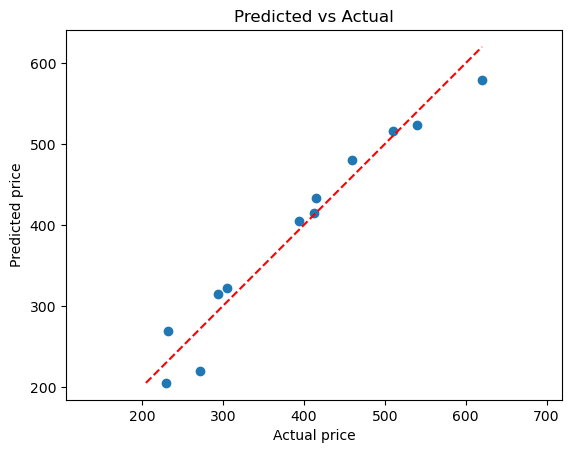

In [150]:
prediction = predict(x_normalized, final_w, final_b)

plt.scatter(y_train, prediction)

lo = min(y_train.min(), prediction.min())
hi = max(y_train.max(), prediction.max())
plt.plot([lo, hi], [lo, hi], color="red", linestyle="--")

plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Predicted vs Actual")
plt.axis('equal')
plt.show()

In [155]:
data = (np.array([1200, 3, 1, 40]) - mean)/sigma
final_prediction = predict(data, final_w, final_b)
print(f"Price of 1200 sqft 3 bedroom 1 floor 40 year old house is {final_prediction:.2f}")

Price of 1200 sqft 3 bedroom 1 floor 40 year old house is 347.11
